In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn imports
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, silhouette_score, adjusted_rand_score, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

# Ensure plots are displayed inline
%matplotlib inline

print("Libraries imported successfully.")

Libraries imported successfully.


In [9]:
# ==========================================
# 0. Data Preparation
# ==========================================

# Load the features dataset
# Note: Ensure 'features_data.csv' is in the same folder
data = pd.read_csv('features_data.csv')

# Separate features and label
X = data.drop('label', axis=1)
y = data['label']

# Split into training and validation sets (80/20 split)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Save the splits to CSV files (optional step from original code)
X_train.assign(label=y_train).to_csv('train_set.csv', index=False)
X_val.assign(label=y_val).to_csv('val_set.csv', index=False)

print(f'Data split complete.')
print(f'Train shape: {X_train.shape}, Validation shape: {X_val.shape}')

Data split complete.
Train shape: (319, 1000), Validation shape: (80, 1000)


Tuning Decision Tree hyperparameters...
Best hyperparameters: {'max_depth': 15, 'min_samples_leaf': 4, 'min_samples_split': 2}
Training Accuracy: 0.8934
Validation Accuracy: 0.7375

Classification Report (Validation Set):
              precision    recall  f1-score   support

     culture       0.68      0.65      0.67        20
        news       0.68      0.85      0.76        20
     opinion       0.86      0.60      0.71        20
       sport       0.77      0.85      0.81        20

    accuracy                           0.74        80
   macro avg       0.75      0.74      0.73        80
weighted avg       0.75      0.74      0.73        80



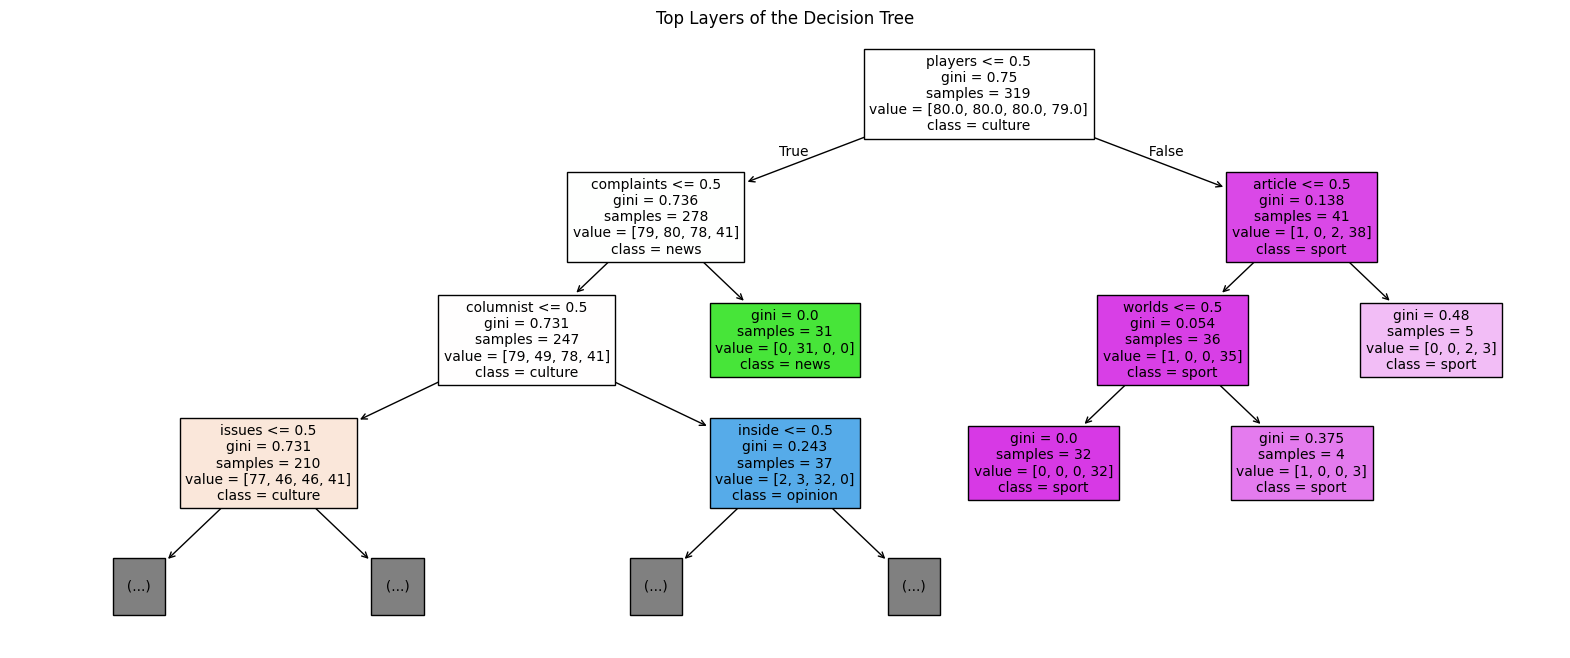

In [10]:
# ==========================================
# Part 1: Decision Tree Classifier
# ==========================================

# Hyperparameter tuning
param_grid_dt = {
    'max_depth': [3, 5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dt = DecisionTreeClassifier(random_state=42)
grid_search_dt = GridSearchCV(dt, param_grid_dt, cv=5, scoring='accuracy', n_jobs=-1)

print("Tuning Decision Tree hyperparameters...")
grid_search_dt.fit(X_train, y_train)

best_dt = grid_search_dt.best_estimator_
print('Best hyperparameters:', grid_search_dt.best_params_)

# Evaluate Decision Tree
y_train_pred_dt = best_dt.predict(X_train)
y_val_pred_dt = best_dt.predict(X_val)

train_acc_dt = accuracy_score(y_train, y_train_pred_dt)
val_acc_dt = accuracy_score(y_val, y_val_pred_dt)

print(f'Training Accuracy: {train_acc_dt:.4f}')
print(f'Validation Accuracy: {val_acc_dt:.4f}')

print('\nClassification Report (Validation Set):')
print(classification_report(y_val, y_val_pred_dt))

# Plot the top layers of the tree
plt.figure(figsize=(20, 8))
plot_tree(best_dt, feature_names=X_train.columns, class_names=[str(c) for c in best_dt.classes_], filled=True, max_depth=3, fontsize=10)
plt.title('Top Layers of the Decision Tree')
plt.show()

Training Default MLP...
Default MLP - Train Acc: 1.0000, Val Acc: 0.8750

Tuning MLP hyperparameters (this may take a moment)...
Best MLP Hyperparameters: {'activation': 'tanh', 'batch_size': 64, 'hidden_layer_sizes': (50,), 'learning_rate_init': 0.01}
Best MLP Validation Accuracy: 0.8750


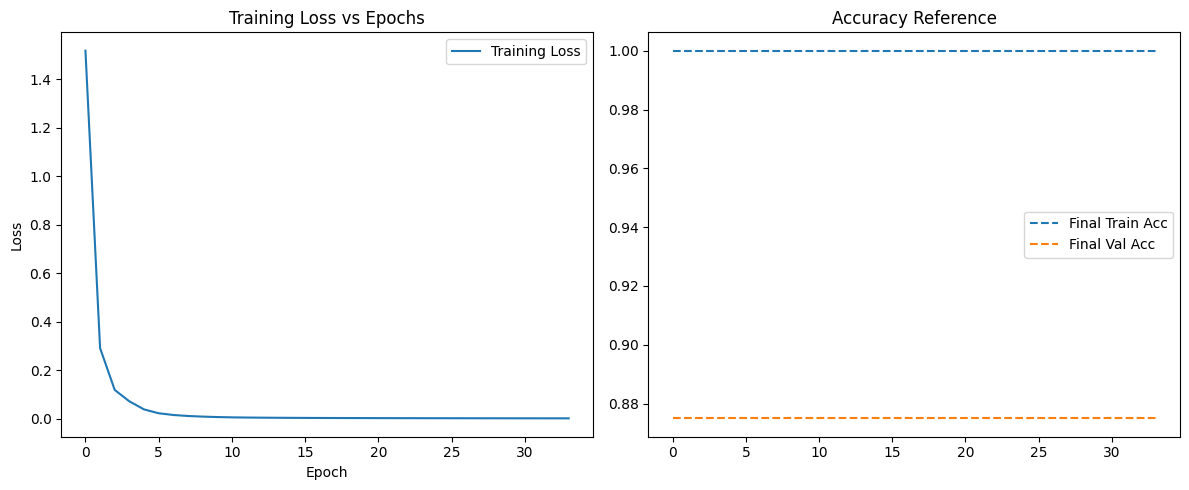

In [11]:
# ==========================================
# Part 2: Neural Network (MLP)
# ==========================================

# A. Train MLP with default parameters
print("Training Default MLP...")
mlp_default = MLPClassifier(random_state=42, max_iter=100)
mlp_default.fit(X_train, y_train)

train_pred_def = mlp_default.predict(X_train)
val_pred_def = mlp_default.predict(X_val)

train_acc_def = accuracy_score(y_train, train_pred_def)
val_acc_def = accuracy_score(y_val, val_pred_def)

print(f'Default MLP - Train Acc: {train_acc_def:.4f}, Val Acc: {val_acc_def:.4f}')

# B. Hyperparameter tuning for MLP
print("\nTuning MLP hyperparameters (this may take a moment)...")
tune_params_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (100, 50)],
    'activation': ['relu', 'tanh'],
    'learning_rate_init': [0.001, 0.01],
    'batch_size': [32, 64]
}

mlp = MLPClassifier(random_state=42, max_iter=100)
gs_mlp = GridSearchCV(mlp, tune_params_mlp, cv=3, scoring='accuracy', n_jobs=-1, return_train_score=True)
gs_mlp.fit(X_train, y_train)

best_mlp = gs_mlp.best_estimator_
train_pred_best_mlp = best_mlp.predict(X_train)
val_pred_best_mlp = best_mlp.predict(X_val)

train_acc_best_mlp = accuracy_score(y_train, train_pred_best_mlp)
val_acc_best_mlp = accuracy_score(y_val, val_pred_best_mlp)

print(f'Best MLP Hyperparameters: {gs_mlp.best_params_}')
print(f'Best MLP Validation Accuracy: {val_acc_best_mlp:.4f}')

# C. Plot performance and loss vs epochs
# Re-training a fresh instance to capture full loss curve
mlp_plot = MLPClassifier(random_state=42, max_iter=50, **gs_mlp.best_params_)
mlp_plot.fit(X_train, y_train)

plt.figure(figsize=(12,5))
# Plot 1: Loss Curve
plt.subplot(1,2,1)
plt.plot(mlp_plot.loss_curve_, label='Training Loss')
plt.title('Training Loss vs Epochs')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()

# Plot 2: Accuracy
plt.subplot(1,2,2)
plt.plot([train_acc_best_mlp]*len(mlp_plot.loss_curve_), label='Final Train Acc', linestyle='--')
plt.plot([val_acc_best_mlp]*len(mlp_plot.loss_curve_), label='Final Val Acc', linestyle='--')
plt.title('Accuracy Reference')
plt.legend()
plt.tight_layout()
plt.show()

Running K-Means for K=2 to 6...


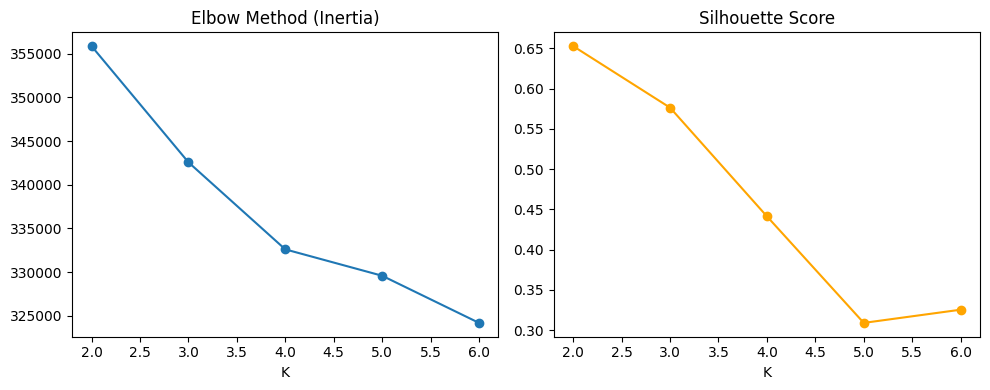

Best K by silhouette: 2


In [12]:
# ==========================================
# Part 3: Clustering Analysis (K-Means)
# ==========================================

# Use all features except label for clustering
feature_cols = [col for col in data.columns if col != 'label']
X_cluster = data[feature_cols]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

inertias = []
silhouettes = []
K_range = range(2, 7)
all_labels = {}

print("Running K-Means for K=2 to 6...")
for K in K_range:
    kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    sil = silhouette_score(X_scaled, labels)
    silhouettes.append(sil)
    all_labels[K] = labels

# Plot metrics
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.plot(list(K_range), inertias, marker='o'); plt.title('Elbow Method (Inertia)'); plt.xlabel('K')
plt.subplot(1,2,2); plt.plot(list(K_range), silhouettes, marker='o', color='orange'); plt.title('Silhouette Score'); plt.xlabel('K')
plt.tight_layout(); plt.show()

# Best K results
best_K = K_range[np.argmax(silhouettes)]
print(f"Best K by silhouette: {best_K}")


--- A. Model Comparison Table ---
           Model  Train Accuracy  Validation Accuracy  Overfitting Gap
0  Decision Tree        0.893417               0.7375         0.155917
1  MLP (Default)        1.000000               0.8750         0.125000
2    MLP (Tuned)        1.000000               0.8750         0.125000

--- B. Visual Analysis (Confusion Matrix) ---


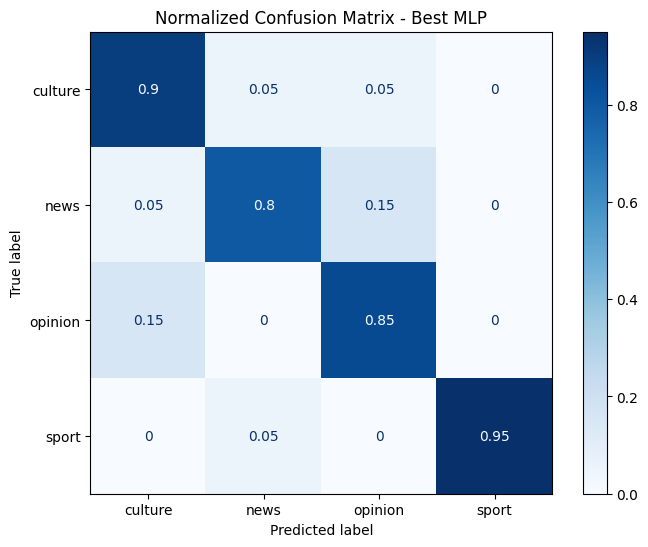


--- C. Overfitting Status ---
Model: Decision Tree   | Gap: 0.1559 | YES Overfitting (15.6%)
Model: MLP (Default)   | Gap: 0.1250 | YES Overfitting (12.5%)
Model: MLP (Tuned)     | Gap: 0.1250 | YES Overfitting (12.5%)


In [13]:
# ==========================================
# Part 4: Final Evaluation (Assignment Requirements)
# ==========================================

print("\n--- A. Model Comparison Table ---")
model_data = {
    'Model': ['Decision Tree', 'MLP (Default)', 'MLP (Tuned)'],
    'Train Accuracy': [train_acc_dt, train_acc_def, train_acc_best_mlp],
    'Validation Accuracy': [val_acc_dt, val_acc_def, val_acc_best_mlp]
}

comparison_df = pd.DataFrame(model_data)
comparison_df['Overfitting Gap'] = comparison_df['Train Accuracy'] - comparison_df['Validation Accuracy']
print(comparison_df)

# B. Visual Analysis (Confusion Matrix)
print("\n--- B. Visual Analysis (Confusion Matrix) ---")
final_model = best_mlp 
model_name = "Best MLP"

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(
    final_model, X_val, y_val, cmap=plt.cm.Blues, normalize='true', ax=ax
)
plt.title(f'Normalized Confusion Matrix - {model_name}')
plt.show()

# C. Overfitting Check
print("\n--- C. Overfitting Status ---")
threshold = 0.05 
for index, row in comparison_df.iterrows():
    gap = row['Overfitting Gap']
    status = f"YES Overfitting ({gap:.1%})" if gap > threshold else "NO Overfitting"
    print(f"Model: {row['Model']:15} | Gap: {gap:.4f} | {status}")

In [14]:
import pandas as pd
import pickle
import re
from sklearn.feature_extraction.text import TfidfVectorizer

try:
    selected_features_df = pd.read_csv('features_data.csv')
    vocabulary_list = selected_features_df.drop('label', axis=1).columns.tolist()
    print(f"Loaded vocabulary with {len(vocabulary_list)} words.")
except FileNotFoundError:
    print("Error")
    raise

df = pd.read_csv("sensed_data.csv")

def clean_text(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = ' '.join(text.split())
    return text

df['combined_text'] = df['title'].apply(clean_text) + " " + df['body'].apply(clean_text)

fixed_vectorizer = TfidfVectorizer(vocabulary=vocabulary_list, stop_words='english')

print("Fitting vectorizer on original text to learn IDF weights...")
fixed_vectorizer.fit(df['combined_text'])

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(fixed_vectorizer, f)

try:
    with open('best_model.pkl', 'wb') as f:
        pickle.dump(best_mlp, f) 
    print("\nSUCCESS! Files saved:")
    print("1. best_model.pkl")
    print("2. tfidf_vectorizer.pkl (Optimized for 1000 features)")
except NameError:
    print("\nWARNING")


Loaded vocabulary with 1000 words.
Fitting vectorizer on original text to learn IDF weights...

SUCCESS! Files saved:
1. best_model.pkl
2. tfidf_vectorizer.pkl (Optimized for 1000 features)
